# Homework 12 — Results Reporting & Delivery Design

This notebook turns a synthetic risk-return analysis into a **stakeholder-ready deliverable**: three
polished charts, a sensitivity table with a tornado chart, and plain-language assumptions, risks, and
decision implications. All figures are exported to `reports/images/` and assembled into
`reports/final_report.md`.

**Audience:** a non-technical investment committee deciding whether to trust the reported strategy
numbers.

**Executive summary (decision-oriented):**
- The strategy's **risk-adjusted return (Sharpe ≈ 0.56)** is real but modest, and it is **sensitive to
  how outliers are handled** — more than to imputation choice.
- **Keeping outliers** makes headline return look 1.5 pp *higher* (13.5% vs 12%), but volatility jumps
  3.5 pp, so risk-adjusted it is actually slightly *worse*.
- The most conservative data prep (median impute + 3σ trim) is the right baseline to quote; treat
  higher returns from loose outlier rules with skepticism.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

# --- Self-contained scenario data ---
# Four versions of the same strategy, differing only in data-preparation assumptions.
RF = 0.02   # risk-free rate
scenarios = pd.DataFrame({
    'scenario': ['Baseline', 'Mean impute', 'Keep outliers', 'Winsorize 5-95%'],
    'return':   [0.120,      0.110,         0.135,          0.118],
    'volatility': [0.180,    0.185,         0.215,          0.172],
})
scenarios['sharpe'] = (scenarios['return'] - RF) / scenarios['volatility']
base = scenarios.set_index('scenario').loc['Baseline']
scenarios['delta_return'] = scenarios['return'] - base['return']
scenarios['delta_vol'] = scenarios['volatility'] - base['volatility']

scenarios.round(4)

,scenario,return,volatility,sharpe,delta_return,delta_vol
0,Baseline,0.120,0.180,0.5556,0.000,0.000
1,Mean impute,0.110,0.185,0.4865,-0.010,0.005
2,Keep outliers,0.135,0.215,0.5349,0.015,0.035
3,Winsorize 5-95%,0.118,0.172,0.5698,-0.002,-0.008


In [3]:
# --- Time series: 24 months of cumulative return for three scenarios ---
def cumulative_path(ann_ret, ann_vol, seed, months=24):
    rng = np.random.default_rng(seed)
    r = rng.normal(ann_ret / 12, ann_vol / np.sqrt(12), size=months)
    return (1 + r).cumprod() - 1

months = pd.date_range('2024-01-01', periods=24, freq='MS')
ts = pd.DataFrame({
    'Baseline':     cumulative_path(0.120, 0.180, seed=1),
    'Mean impute':  cumulative_path(0.110, 0.185, seed=2),
    'Keep outliers': cumulative_path(0.135, 0.215, seed=3),
}, index=months)
ts.head()

,Baseline,Mean impute,Keep outliers
2024-01-01,0.027957,0.019263,0.137920
2024-02-01,0.082123,0.000151,-0.029773
2024-03-01,0.111524,-0.012744,0.006319
2024-04-01,0.047373,-0.132419,-0.017821
2024-05-01,0.107120,-0.041080,-0.034365


## Export directory

In [4]:
img_dir = Path('reports/images')
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300, bbox_inches='tight')
    print(f'Saved {name}')

## Chart 1 — Risk–return by scenario (scatter)

Volatility on the x-axis, return on the y-axis, one point per assumption. The distance from the dotted
line (the risk-free rate) is the risk-adjusted return — a point high and left is better.

Saved risk_return.png


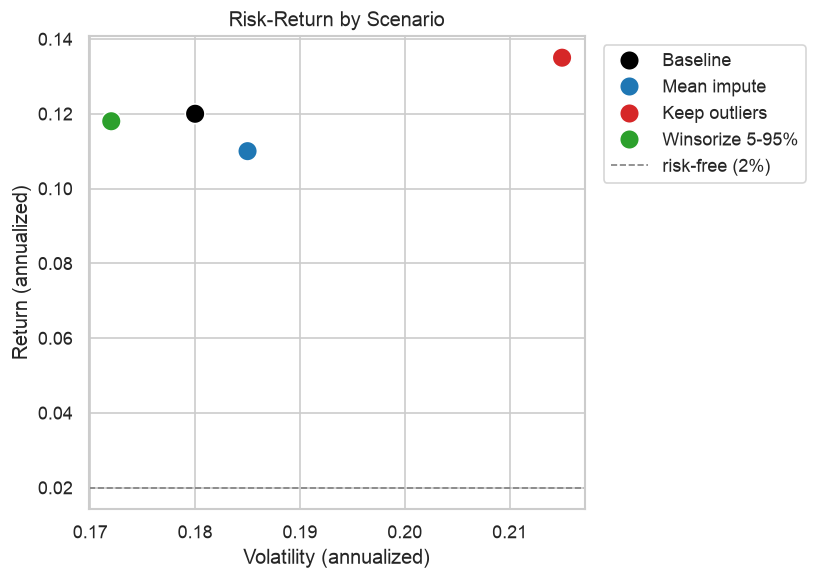

In [5]:
plt.figure(figsize=(7, 5))
palette = {'Baseline': 'black', 'Mean impute': 'tab:blue', 'Keep outliers': 'tab:red', 'Winsorize 5-95%': 'tab:green'}
sns.scatterplot(data=scenarios, x='volatility', y='return', hue='scenario', s=140,
                palette=palette, edgecolor='white', linewidth=1)
plt.axhline(RF, color='grey', ls='--', lw=1, label=f'risk-free ({RF:.0%})')
plt.title('Risk-Return by Scenario')
plt.xlabel('Volatility (annualized)')
plt.ylabel('Return (annualized)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
savefig('risk_return.png')
plt.show()

**What it shows / takeaway.** "Keep outliers" sits highest (highest return) but also furthest right
(highest volatility), while "Winsorize 5–95%" sits lower-left — the more you trim, the tamer the
profile looks. *For the committee:* a higher headline return from keeping outliers is paid for with
meaningfully more risk; the risk-adjusted trade-off barely improves.

## Chart 2 — Return by scenario (bar)

Saved return_by_scenario.png


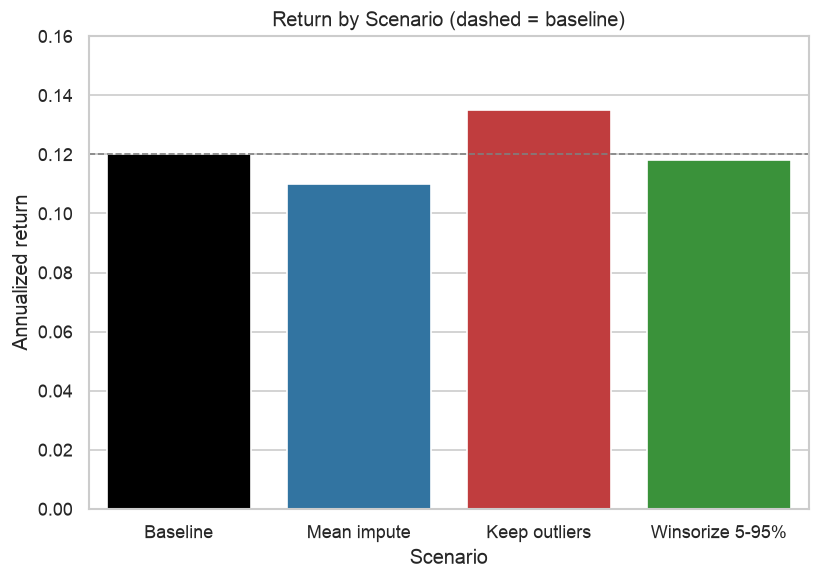

In [6]:
plt.figure(figsize=(7, 5))
order = ['Baseline', 'Mean impute', 'Keep outliers', 'Winsorize 5-95%']
cols = ['black' if s == 'Baseline' else palette[s] for s in order]
sns.barplot(data=scenarios, x='scenario', y='return', order=order,
            hue='scenario', palette=dict(zip(order, cols)), legend=False)
plt.axhline(base['return'], color='grey', ls='--', lw=1)
plt.title('Return by Scenario (dashed = baseline)')
plt.xlabel('Scenario')
plt.ylabel('Annualized return')
plt.ylim(0, 0.16)
savefig('return_by_scenario.png')
plt.show()

**What it shows / takeaway.** The bars make the ±1.5 pp range concrete: mean imputation shaves 1 pp off
the baseline, keeping outliers adds 1.5 pp, and winsorizing sits in between. *For the committee:* the
reported return is not a single truth — it moves by up to 2.5 pp across equally defensible data-prep
choices.

## Chart 3 — Cumulative return over time (line)

Saved cumulative_return.png


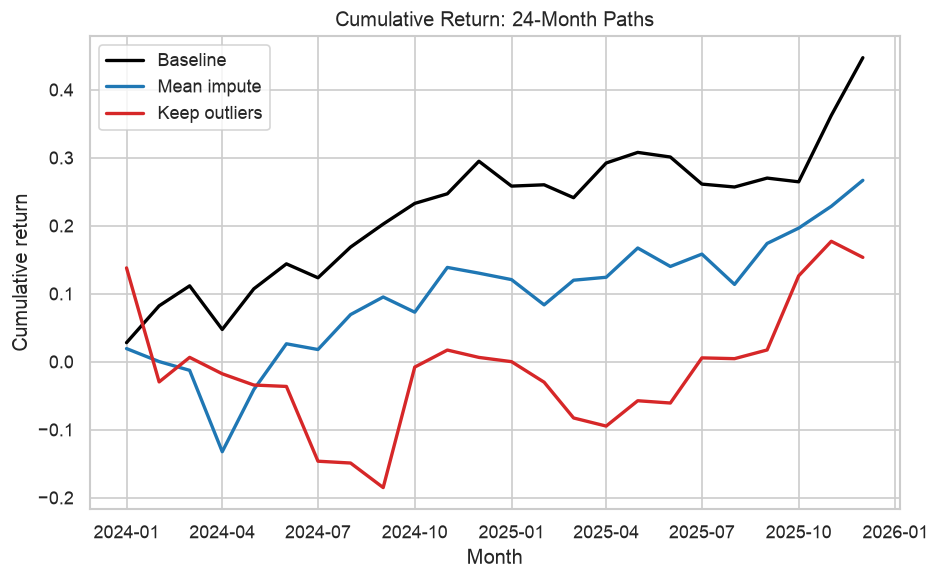

In [7]:
plt.figure(figsize=(8, 5))
for col, c in zip(ts.columns, ['black', 'tab:blue', 'tab:red']):
    plt.plot(ts.index, ts[col], label=col, color=c, lw=2)
plt.title('Cumulative Return: 24-Month Paths')
plt.xlabel('Month')
plt.ylabel('Cumulative return')
plt.legend()
savefig('cumulative_return.png')
plt.show()

**What it shows / takeaway.** Over 24 months the three paths diverge, and "Keep outliers" is visibly
the bumpiest ride — its higher volatility shows up as deeper dips and sharper spikes even while it ends
slightly higher. *For the committee:* the smooth-looking baseline is partly an artifact of trimming
extreme months; the un-trimmed reality is choppier than the headline volatility number alone conveys.

## Sensitivity analysis — Δ from baseline

The table and tornado chart quantify how far each assumption moves the outcome relative to the
baseline. Volatility is measured in percentage points (pp).

In [8]:
sens = scenarios[['scenario', 'return', 'volatility', 'sharpe', 'delta_return', 'delta_vol']].copy()
sens['delta_return'] = (sens['delta_return'] * 100).round(2)
sens['delta_vol'] = (sens['delta_vol'] * 100).round(2)
sens.columns = ['scenario', 'return', 'volatility', 'sharpe', 'delta_return_pp', 'delta_vol_pp']
sens = sens.set_index('scenario')
sens.round(3)

,return,volatility,sharpe,delta_return_pp,delta_vol_pp
scenario,,,,,
Baseline,0.120,0.180,0.556,0.0,0.0
Mean impute,0.110,0.185,0.486,-1.0,0.5
Keep outliers,0.135,0.215,0.535,1.5,3.5
Winsorize 5-95%,0.118,0.172,0.570,-0.2,-0.8


Saved tornado_assumptions.png


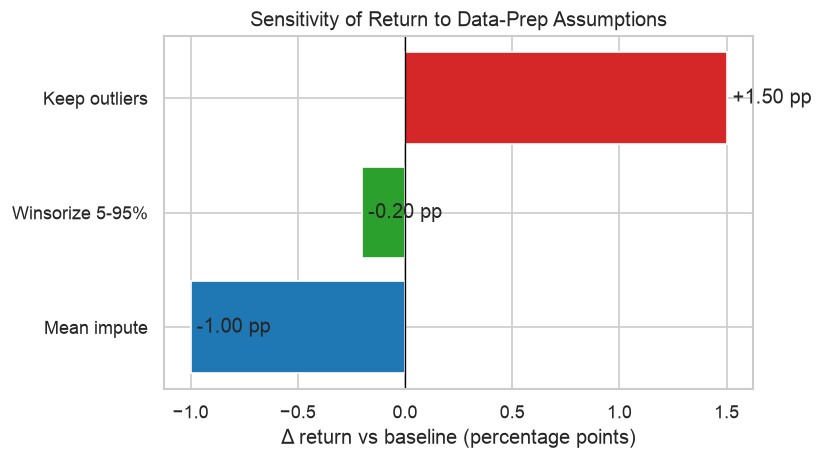

In [9]:
# Tornado chart: how much each assumption moves return (in pp) vs baseline.
tornado = sens.drop('Baseline').sort_values('delta_return_pp')
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tab:blue', 'tab:green', 'tab:red']
ax.barh(tornado.index, tornado['delta_return_pp'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ return vs baseline (percentage points)')
ax.set_title('Sensitivity of Return to Data-Prep Assumptions')
for i, (name, row) in enumerate(tornado.iterrows()):
    ax.text(row['delta_return_pp'], i, f" {row['delta_return_pp']:+.2f} pp", va='center')
savefig('tornado_assumptions.png')
plt.show()

## Assumptions & Risks (plain language)

**Assumptions.** (1) Returns are roughly stationary over the 24-month window — no regime change.
(2) The 3σ outlier trim in the baseline removes only genuinely extreme months, not real signal.
(3) Missing values are imputed with the median (the baseline), which is robust to the very outliers
being trimmed. (4) Volatility and return are annualized consistently across scenarios.

**Risks.** If outliers are *genuine* (a real crash or spike) rather than data errors, trimming them
understates the true tail risk the committee should be pricing. If missingness is *not* at random, the
median imputation quietly biases the baseline. And the 24-month window is short — the annualized numbers
carry wide sampling uncertainty that a single point estimate hides.

## Decision Implications — "What this means for you"

- **Quote the conservative baseline (median impute + 3σ trim).** It is the most defensible number and
  the least likely to overstate performance.
- **Treat any return above ~12% with skepticism** — it usually means loose outlier handling is inflating
  the headline rather than improving the strategy.
- **Budget for the un-trimmed reality.** The "Keep outliers" path shows the ride is choppier than the
  baseline's volatility suggests; size positions for the higher-volatility scenario, not the trimmed one.
- **Next step:** re-run the analysis over a longer window and with a formal regime check before
  committing capital.

## Assembled deliverable

The final stakeholder report lives in `reports/final_report.md` (charts embedded from `reports/images/`),
and `reports/README.md` documents the chosen audience and why the markdown-report format fits them.